# Effect of Vulnerability Context Size on LLM Detection Performance

This notebook investigates **how the amount of code context surrounding a vulnerability
affects LLM detection quality**, on two complementary datasets:

| | Dataset A — CleanVul size buckets | Dataset B — ContextAssembler budget sweep |
|---|---|---|
| Results root | `results/cleanvul_experiments/context_size_comparison` | `results/context_assembler_compare_rankings_experiments/context_sizes{,_gemma}` |
| What varies | **Natural size** of the target function(s): samples are bucketed by code token count (0–1k, 1–2k, 2–4k, 4–8k, 8–16k) | **Assembled context budget** for the *same* 346 samples (1k, 2k, 4k, 8k, 16k tokens), under several context-ranking strategies |
| Design | Cross-sectional — *different* samples per bucket (but vuln/benign pairs share a commit) | Repeated measures — *the same sample* is evaluated at every budget |
| Consequence | Buckets are compared with **unpaired** tests; regressions use per-sample `log2(code_tokens)` with commit + project random intercepts | Budgets are compared with **paired** tests (McNemar); regressions use `log2(budget)` with sample + project random intercepts |

**Metrics**: Accuracy, F1 (positive class = vulnerable), FNR = FN/(FN+TP), and **MCC**
(Matthews correlation coefficient — robust to class imbalance, recommended as the primary
metric). All point estimates come with **95% cluster-bootstrap confidence intervals**.

**Statistical analysis** (details in the *Statistical methodology* section below):
mixed-effects logistic regression for correctness with a quadratic `log2(size)` term
(tests the inverted-U hypothesis), McNemar's test with Holm correction for pairwise budget
comparisons, mixed-effects logistic regression for hallucination rate, and a mixed linear
model for latency.

> **Re-running with new results**: the loaders below *discover* whatever benchmark reports
> currently exist and take the latest report per (dataset, model, prompt) cell. Missing
> cells (e.g. models still running) are listed in the coverage tables and are simply
> absent from plots/tables — re-execute the notebook once new results land.

In [1]:
import json
import re
import warnings
from itertools import combinations
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

# --- configuration -----------------------------------------------------------
ROOT = Path.cwd()
if not (ROOT / "results").exists():          # notebook lives in benchmarks/
    ROOT = ROOT.parent
assert (ROOT / "results").exists(), f"cannot locate repo root from {Path.cwd()}"

A_RESULTS = ROOT / "results/cleanvul_experiments/context_size_comparison"
A_DATASETS = ROOT / "datasets_processed/cleanvul/context_sizes"
A_PLAN_CONFIG = ROOT / "src/configs/cleanvul_experiments.json"

B_RESULTS = [
    ROOT / "results/context_assembler_compare_rankings_experiments/context_sizes",
    ROOT / "results/context_assembler_compare_rankings_experiments/context_sizes_gemma",
]
B_ENTRIES = ROOT / "datasets_processed/context_assembler_compare_rankings/cleanvul_entries.json"

N_BOOT = 2000                 # bootstrap replicates
SEED = 20260709
ALPHA = 0.05
TABLES_DIR = ROOT / "benchmarks/tables"
TABLES_DIR.mkdir(exist_ok=True)

BUCKET_ORDER = ["0k_1k", "1k_2k", "2k_4k", "4k_8k", "8k_16k"]
BUCKET_LABEL = {"0k_1k": "0–1k", "1k_2k": "1–2k", "2k_4k": "2–4k",
                "4k_8k": "4–8k", "8k_16k": "8–16k"}
BUDGET_ORDER_K = [1, 2, 4, 8, 16]

# --- chart style (single accent + de-emphasis gray; validated reference palette)
ACCENT = "#2a78d6"        # emphasis series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRAY_CTX = "#c3c2b7"      # context series
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
from matplotlib.colors import LinearSegmentedColormap
DIV_CMAP = LinearSegmentedColormap.from_list(   # red (low) <-> white <-> blue (high)
    "div_rb", ["#e34948", "#f7f6f3", "#2a78d6"])
DIV_CMAP_R = DIV_CMAP.reversed()                # for lower-is-better metrics (FNR)

_SIZE_RE = re.compile(r"(?i)^e?\d+(?:\.\d+)?b$")


def short_model(name: str) -> str:
    """Plot label: model family + parameter size only, e.g.
    'gemma4-26b-a4b-gguf' -> 'gemma4 26B', 'qwen3-8b-thinking' -> 'qwen3 8B'."""
    parts = name.split("-")
    size = next((p for p in parts[1:] if _SIZE_RE.match(p)), None)
    return f"{parts[0]} {size.upper()}" if size else name

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY_CTX, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "figure.facecolor": "white", "axes.facecolor": SURFACE,
    "axes.titlesize": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
rng_global = np.random.default_rng(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
print(f"repo root: {ROOT}")

repo root: /var/opt/llm4codesec-framework


## 1. Load benchmark reports

One row per model prediction. A prediction is **valid** if the framework parsed a binary
label out of the model response (`is_success` and `predicted_label ∈ {0, 1}`); metrics are
computed on valid predictions, and the invalid fraction is reported separately as the
*parse-failure rate*.

In [2]:
def _latest_report(cell_dir: Path):
    """Newest benchmark_report_*.json in a cell directory (timestamped filenames sort)."""
    reports = sorted(cell_dir.glob("benchmark_report_*.json"))
    return reports[-1] if reports else None


def _project_from_url(url: str) -> str:
    parts = [p for p in urlparse(str(url)).path.split("/") if p]
    return "/".join(parts[:2]) if len(parts) >= 2 else str(url)


def _prediction_rows(report: dict) -> list[dict]:
    rows = []
    for p in report.get("predictions", []):
        pred = p.get("predicted_label")
        valid = bool(p.get("is_success")) and pred in (0, 1)
        inf = p.get("inference_data") or {}
        rows.append({
            "sample_id": p["sample_id"],
            "y_true": int(p["true_label"]),
            "y_pred": int(pred) if valid else np.nan,
            "valid": valid,
            "latency_s": inf.get("processing_time"),
            "tokens_used": inf.get("tokens_used"),
        })
    return rows


# ---- Dataset A: CleanVul natural-size buckets --------------------------------
def load_dataset_a() -> pd.DataFrame:
    # sample_id -> (code_tokens, project, commit) from the processed dataset files
    meta = {}
    for b in BUCKET_ORDER:
        f = A_DATASETS / f"cleanvul_py_binary_{b}.json"
        if not f.exists():
            continue
        for s in json.loads(f.read_text())["samples"]:
            m = s.get("metadata", {})
            commit = s["id"].split("_")[1] if s["id"].count("_") >= 2 else s["id"]
            meta[s["id"]] = {
                "code_tokens": m.get("code_tokens"),
                "project": _project_from_url(m.get("commit_url", "")),
                "commit": commit,
            }
    rows = []
    for bucket_dir in sorted(A_RESULTS.glob("ctx_py_*")):
        bucket = bucket_dir.name.removeprefix("ctx_py_")
        for model_dir in sorted(p for p in bucket_dir.iterdir() if p.is_dir()):
            for prompt_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
                rep_file = _latest_report(prompt_dir)
                if rep_file is None:
                    continue
                report = json.loads(rep_file.read_text())
                for r in _prediction_rows(report):
                    r.update(bucket=bucket, model=model_dir.name,
                             prompt=prompt_dir.name, report=rep_file.name,
                             **meta.get(r["sample_id"], {}))
                    rows.append(r)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["bucket"] = pd.Categorical(df["bucket"], categories=BUCKET_ORDER, ordered=True)
    df["correct"] = (df["valid"] & (df["y_pred"] == df["y_true"])).astype(int)
    return df


# ---- Dataset B: ContextAssembler budget sweep ---------------------------------
_B_DIR_RE = re.compile(r"^context_assembler_compare_(.+)_(\d+)k$")


def load_dataset_b() -> pd.DataFrame:
    entries = {e["sample_id"]: _project_from_url(e["repo_url"])
               for e in json.loads(B_ENTRIES.read_text())} if B_ENTRIES.exists() else {}
    # latest report per (ranking, budget, model, prompt) across both result roots
    cells = {}
    for root in B_RESULTS:
        if not root.exists():
            continue
        for exp_dir in root.iterdir():
            m = _B_DIR_RE.match(exp_dir.name)
            if not m:
                continue
            ranking, budget_k = m.group(1), int(m.group(2))
            for model_dir in sorted(p for p in exp_dir.iterdir() if p.is_dir()):
                for prompt_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
                    rep = _latest_report(prompt_dir)
                    if rep is None:
                        continue
                    key = (ranking, budget_k, model_dir.name, prompt_dir.name)
                    if key not in cells or rep.name > cells[key].name:
                        cells[key] = rep
    rows = []
    for (ranking, budget_k, model, prompt), rep_file in cells.items():
        report = json.loads(rep_file.read_text())
        for r in _prediction_rows(report):
            r.update(ranking=ranking, budget_k=budget_k, model=model, prompt=prompt,
                     project=entries.get(r["sample_id"], "unknown"),
                     report=rep_file.name)
            rows.append(r)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["correct"] = (df["valid"] & (df["y_pred"] == df["y_true"])).astype(int)
    return df


df_a = load_dataset_a()
df_b = load_dataset_b()


print(f"Dataset A: {len(df_a):>6} predictions, models: {sorted(df_a['model'].unique()) if not df_a.empty else '—'}")
print(f"Dataset B: {len(df_b):>6} predictions, models: {sorted(df_b['model'].unique()) if not df_b.empty else '—'}")
if not df_b.empty:
    print(f"Dataset B — all analyses pool these ranking strategies into a per-model "
          f"average: {sorted(df_b['ranking'].unique())}")

Dataset A:   1556 predictions, models: ['gemma4-12b-it-thinking', 'gemma4-e4b-it', 'qwen3-4b-thinking', 'qwen3-8b-thinking']
Dataset B:  63310 predictions, models: ['gemma4-12b-it-thinking', 'gemma4-26b-a4b-gguf', 'gemma4-e4b-it', 'qwen3-14b-gguf-thinking', 'qwen3-30b-a3b-instruct-gguf', 'qwen3-4b-thinking', 'qwen3-8b-thinking']
Dataset B — all analyses pool these ranking strategies into a per-model average: ['cpg_structural', 'current', 'current_default', 'depth_repeats_context', 'dummy', 'evidence_budgeted', 'multiplicative_boost', 'multiplicative_boost_default', 'random_picking']


### 1.1 Coverage — which cells exist so far

Cells show the number of predictions loaded (latest report per cell). `—` means the
experiment has not produced a report yet; re-run the notebook when it has. Small counts
flag partial/smoke runs and small buckets (the 8–16k CleanVul bucket currently has few
Python samples).

In [3]:
# planned models for Dataset A come from the experiment plan config
try:
    _plan = json.loads(A_PLAN_CONFIG.read_text())["experiment_plans"]["context_size_comparison"]
    A_PLANNED_MODELS = list(_plan["models"])
except Exception:
    A_PLANNED_MODELS = sorted(df_a["model"].unique()) if not df_a.empty else []

if not df_a.empty:
    cov_a = (df_a.groupby(["model", "bucket"], observed=False).size()
                 .unstack("bucket").reindex(A_PLANNED_MODELS))
    cov_a.columns = [BUCKET_LABEL.get(str(c), str(c)) for c in cov_a.columns]
    print("Dataset A — predictions per (model, bucket):")
    display(cov_a.fillna(0).astype(int).replace(0, "—"))
    missing = cov_a.isna().all(axis=1)
    if missing.any():
        print("Not started yet:", ", ".join(cov_a.index[missing]))

if not df_b.empty:
    cov_b = (df_b.groupby(["model", "budget_k"]).size().unstack("budget_k")
             .fillna(0).astype(int).replace(0, "—"))
    cov_b.insert(0, "rankings", df_b.groupby("model")["ranking"].nunique())
    print("\nDataset B — predictions per (model, budget), pooled over all rankings:")
    display(cov_b)
    print(f"\nDataset B — cells per ranking (all models/budgets):")
    display(df_b.groupby("ranking")[["budget_k", "model"]]
                .agg(budgets=("budget_k", "nunique"), models=("model", "nunique")))

Dataset A — predictions per (model, bucket):


,0–1k,1–2k,2–4k,4–8k,8–16k
model,,,,,
gemma4-12b-it-thinking,200,89,55,32,13
qwen3-8b-thinking,200,89,55,32,13
qwen3-4b-thinking,200,89,55,32,13
gemma4-e4b-it,200,89,55,32,13
qwen3-30b-a3b-instruct-gguf,—,—,—,—,—
gemma4-26b-a4b-gguf-thinking,—,—,—,—,—


Not started yet: qwen3-30b-a3b-instruct-gguf, gemma4-26b-a4b-gguf-thinking

Dataset B — predictions per (model, budget), pooled over all rankings:


budget_k,rankings,1,2,4,8,16
model,,,,,,
gemma4-12b-it-thinking,9,3114,3600,3384,3600,3598
gemma4-26b-a4b-gguf,3,1038,1200,1128,1198,1091
gemma4-e4b-it,3,1038,1200,1128,1200,1199
qwen3-14b-gguf-thinking,3,1038,1200,1128,1200,1200
qwen3-30b-a3b-instruct-gguf,3,1038,1200,1128,1198,1200
qwen3-4b-thinking,3,1038,1200,1128,1200,1200
qwen3-8b-thinking,9,3114,3600,3384,3600,3600



Dataset B — cells per ranking (all models/budgets):


,budgets,models
ranking,,
cpg_structural,5,7
current,5,2
current_default,5,2
depth_repeats_context,5,7
dummy,5,2
evidence_budgeted,5,2
multiplicative_boost,5,7
multiplicative_boost_default,5,2
random_picking,5,2


## 2. Metrics with cluster-bootstrap confidence intervals

For each cell we compute Accuracy, F1, FNR and MCC on the valid predictions. 95% CIs are
**cluster bootstrap** percentile intervals (2000 replicates): resampling clusters rather
than rows respects the dependence structure —

* Dataset A: clusters = **commits** (each commit contributes a vulnerable *and* a benign sample);
* Dataset B: clusters = **samples** (one row per sample inside a cell).

In [4]:
def _counts(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn


def binary_metrics(y_true, y_pred):
    tp, tn, fp, fn = _counts(y_true, y_pred)
    n = tp + tn + fp + fn
    acc = (tp + tn) / n if n else np.nan
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    denom = np.sqrt(float(tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / denom if denom else np.nan
    return {"Accuracy": acc, "F1": f1, "FNR": fnr, "MCC": mcc}


METRIC_NAMES = ["Accuracy", "F1", "FNR", "MCC"]


def bootstrap_metrics(cell_df, cluster_col, n_boot=N_BOOT, seed=SEED):
    """Point estimates + cluster-bootstrap percentile 95% CIs for one cell."""
    d = cell_df[cell_df["valid"]]
    out = {"n": len(d), "n_pos": int((d["y_true"] == 1).sum())}
    if d.empty:
        out.update({m: np.nan for m in METRIC_NAMES})
        return out
    y_true = d["y_true"].to_numpy()
    y_pred = d["y_pred"].to_numpy().astype(int)
    out.update(binary_metrics(y_true, y_pred))

    codes, _ = pd.factorize(d[cluster_col].fillna(d["sample_id"]))
    n_clusters = codes.max() + 1
    cluster_rows = [np.flatnonzero(codes == c) for c in range(n_clusters)]
    rng = np.random.default_rng(seed)
    boots = {m: np.empty(n_boot) for m in METRIC_NAMES}
    for i in range(n_boot):
        picked = rng.integers(0, n_clusters, n_clusters)
        idx = np.concatenate([cluster_rows[c] for c in picked])
        for m, v in binary_metrics(y_true[idx], y_pred[idx]).items():
            boots[m][i] = v
    for m in METRIC_NAMES:
        vals = boots[m][~np.isnan(boots[m])]
        if len(vals):
            out[f"{m}_lo"], out[f"{m}_hi"] = np.percentile(vals, [2.5, 97.5])
        else:
            out[f"{m}_lo"] = out[f"{m}_hi"] = np.nan
    return out


def metrics_table(df, group_cols, cluster_col):
    recs = []
    for keys, g in df.groupby(group_cols, observed=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rec = dict(zip(group_cols, keys))
        rec.update(bootstrap_metrics(g, cluster_col))
        recs.append(rec)
    return pd.DataFrame(recs)


tab_a = (metrics_table(df_a, ["model", "bucket"], "commit")
         if not df_a.empty else pd.DataFrame())
# Dataset B pools all ranking strategies: metrics are computed on the pooled
# predictions (equivalent to the rankings average), with the bootstrap clustered by
# sample so the repeats of each sample across rankings do not shrink the CIs.
tab_b = (metrics_table(df_b, ["model", "budget_k"], "sample_id")
         if not df_b.empty else pd.DataFrame())

if not tab_a.empty:
    print("Dataset A (per model × bucket):")
    display(tab_a.round(3))
if not tab_b.empty:
    print("Dataset B (per model × budget, pooled over all rankings):")
    display(tab_b.round(3))

Dataset A (per model × bucket):


,model,bucket,n,n_pos,Accuracy,F1,FNR,MCC,Accuracy_lo,Accuracy_hi,F1_lo,F1_hi,FNR_lo,FNR_hi,MCC_lo,MCC_hi
0,gemma4-12b-it-thinking,0k_1k,200,100,0.520,0.284,0.810,0.053,0.488,0.553,0.189,0.374,0.727,0.882,-0.033,0.143
1,gemma4-12b-it-thinking,1k_2k,89,46,0.539,0.406,0.696,0.108,0.477,0.600,0.267,0.514,0.562,0.830,-0.019,0.238
2,gemma4-12b-it-thinking,2k_4k,55,26,0.509,0.341,0.731,-0.007,0.434,0.588,0.167,0.481,0.560,0.889,-0.180,0.167
3,gemma4-12b-it-thinking,4k_8k,32,16,0.500,0.500,0.500,0.000,0.375,0.625,0.307,0.649,0.250,0.750,-0.258,0.252
4,gemma4-12b-it-thinking,8k_16k,13,7,0.462,0.364,0.714,-0.051,0.231,0.692,0.000,0.667,0.429,1.000,-0.529,0.429
5,gemma4-e4b-it,0k_1k,200,100,0.450,0.329,0.730,-0.107,0.404,0.497,0.248,0.406,0.640,0.812,-0.204,-0.008
6,gemma4-e4b-it,1k_2k,89,46,0.427,0.414,0.609,-0.144,0.360,0.484,0.301,0.505,0.468,0.745,-0.279,-0.024
7,gemma4-e4b-it,2k_4k,55,26,0.527,0.458,0.577,0.045,0.444,0.618,0.311,0.586,0.391,0.759,-0.127,0.231
8,gemma4-e4b-it,4k_8k,32,16,0.375,0.412,0.562,-0.252,0.250,0.500,0.214,0.564,0.312,0.812,-0.516,0.000
9,gemma4-e4b-it,8k_16k,13,7,0.462,0.222,0.857,-0.033,0.231,0.692,0.000,0.600,0.571,1.000,-0.592,0.507


Dataset B (per model × budget, pooled over all rankings):


,model,budget_k,n,n_pos,Accuracy,F1,FNR,MCC,Accuracy_lo,Accuracy_hi,F1_lo,F1_hi,FNR_lo,FNR_hi,MCC_lo,MCC_hi
0,gemma4-12b-it-thinking,1,3114,1557,0.582,0.567,0.452,0.164,0.544,0.621,0.516,0.616,0.399,0.507,0.089,0.242
1,gemma4-12b-it-thinking,2,3600,1800,0.560,0.566,0.427,0.120,0.525,0.596,0.521,0.608,0.380,0.476,0.051,0.193
2,gemma4-12b-it-thinking,4,3384,1692,0.570,0.596,0.365,0.142,0.535,0.604,0.549,0.639,0.315,0.415,0.072,0.211
3,gemma4-12b-it-thinking,8,3600,1800,0.557,0.570,0.413,0.114,0.523,0.591,0.523,0.614,0.364,0.465,0.046,0.183
4,gemma4-12b-it-thinking,16,3598,1799,0.556,0.573,0.403,0.112,0.522,0.592,0.528,0.618,0.351,0.454,0.045,0.182
5,gemma4-26b-a4b-gguf,1,1038,519,0.571,0.573,0.424,0.143,0.524,0.617,0.513,0.630,0.358,0.488,0.046,0.234
6,gemma4-26b-a4b-gguf,2,1200,600,0.576,0.583,0.407,0.152,0.534,0.617,0.535,0.630,0.350,0.462,0.069,0.235
7,gemma4-26b-a4b-gguf,4,1128,564,0.583,0.596,0.387,0.167,0.539,0.628,0.542,0.647,0.326,0.447,0.080,0.255
8,gemma4-26b-a4b-gguf,8,1198,599,0.549,0.553,0.442,0.099,0.507,0.590,0.497,0.602,0.384,0.506,0.014,0.180
9,gemma4-26b-a4b-gguf,16,1091,548,0.554,0.558,0.440,0.107,0.512,0.595,0.506,0.606,0.379,0.496,0.024,0.190


## 3. Overview — every measurement at a glance

One panel per measurement, both datasets, **all available results**. Thin gray lines
are individual models (Dataset B: each model averaged over all ranking strategies); the blue
line is the cross-model mean. This is the "general shape" view — per-model detail
follows in §4/§5.

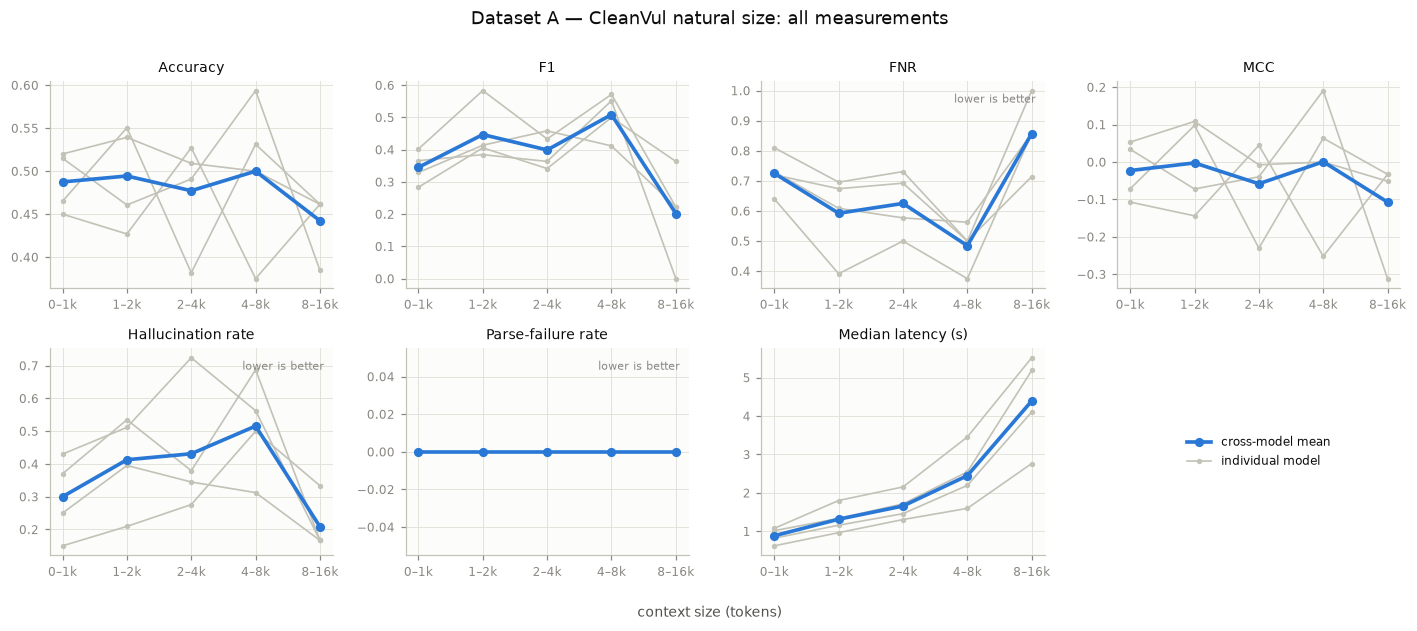

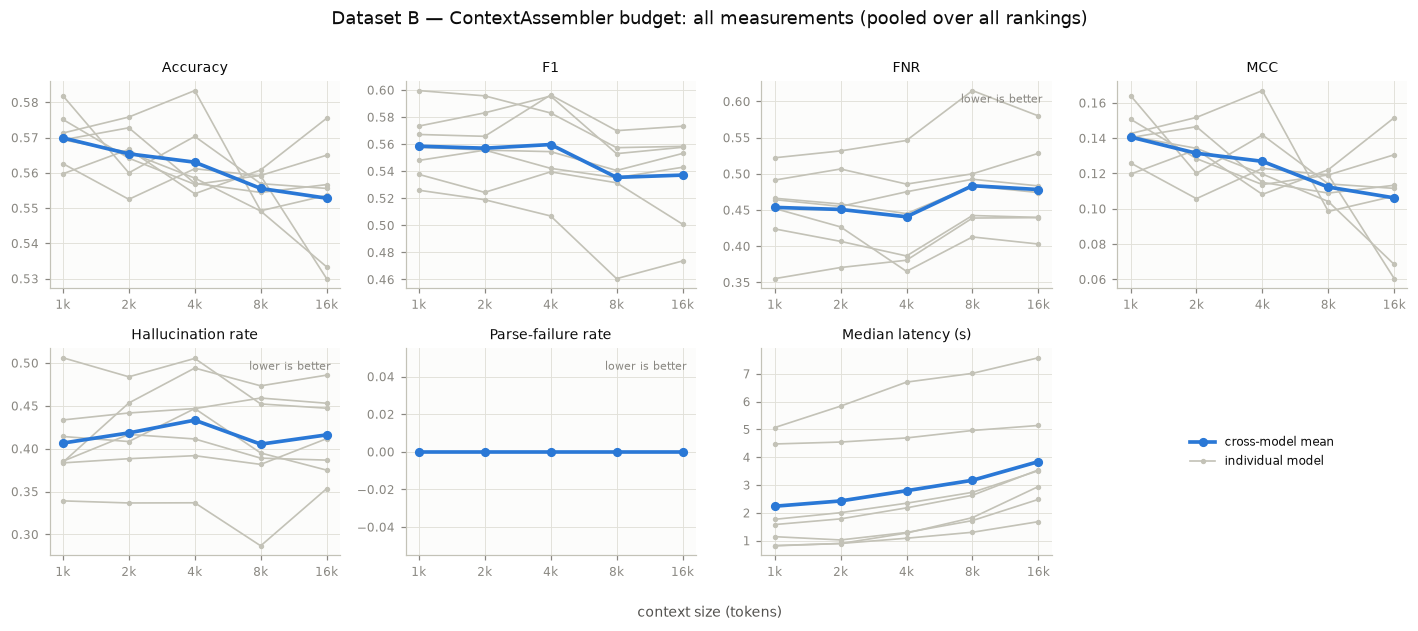

In [5]:
MEASUREMENTS = ["Accuracy", "F1", "FNR", "MCC",
                "Hallucination rate", "Parse-failure rate", "Median latency (s)"]


def measurement_frame(df, size_col):
    """All measured quantities per (model, size)."""
    rows = []
    for (model, size), g in df.groupby(["model", size_col], observed=True):
        v = g[g["valid"]]
        rec = {"model": model, "size": size}
        if len(v):
            rec.update(binary_metrics(v["y_true"].to_numpy(),
                                      v["y_pred"].to_numpy().astype(int)))
        else:
            rec.update({m: np.nan for m in METRIC_NAMES})
        ben = v[v["y_true"] == 0]
        rec["Hallucination rate"] = float((ben["y_pred"] == 1).mean()) if len(ben) else np.nan
        rec["Parse-failure rate"] = 1.0 - float(g["valid"].mean())
        rec["Median latency (s)"] = (float(g["latency_s"].median())
                                     if g["latency_s"].notna().any() else np.nan)
        rows.append(rec)
    return pd.DataFrame(rows)


def _size_x(values, size_col):
    if size_col == "bucket":
        pos = {b: i for i, b in enumerate(BUCKET_ORDER)}
        return np.array([pos[str(v)] for v in values], dtype=float)
    return np.asarray(values, dtype=float)


def _size_axis(ax, size_col, labels_on=True):
    if size_col == "bucket":
        ax.set_xticks(range(len(BUCKET_ORDER)),
                      [BUCKET_LABEL[b] for b in BUCKET_ORDER] if labels_on else [])
    else:
        ax.set_xscale("log", base=2)
        ax.set_xticks(BUDGET_ORDER_K,
                      [f"{k}k" for k in BUDGET_ORDER_K] if labels_on else [])
        ax.minorticks_off()


def overview_figure(mf, size_col, title):
    fig, axes = plt.subplots(2, 4, figsize=(13, 5.6))
    for ax, meas in zip(axes.flat, MEASUREMENTS):
        for _, g in mf.groupby("model"):
            g = g.dropna(subset=[meas])
            if g.empty:
                continue
            x = _size_x(g["size"], size_col)
            order = np.argsort(x)
            ax.plot(x[order], g[meas].to_numpy()[order], color=GRAY_CTX,
                    lw=1.1, marker="o", ms=2.5, zorder=2)
        mean = mf.groupby("size", observed=True)[meas].mean().dropna()
        if not mean.empty:
            x = _size_x(mean.index, size_col)
            order = np.argsort(x)
            ax.plot(x[order], mean.to_numpy()[order], color=ACCENT, lw=2.4,
                    marker="o", ms=5, zorder=3)
        ax.set_title(meas, color=INK)
        _size_axis(ax, size_col)
        if meas in ("FNR", "Hallucination rate", "Parse-failure rate"):
            ax.annotate("lower is better", xy=(0.97, 0.94), xycoords="axes fraction",
                        ha="right", va="top", fontsize=7, color=MUTED)
    ax = axes.flat[-1]                       # legend panel in the unused 8th slot
    ax.axis("off")
    ax.plot([], [], color=ACCENT, lw=2.4, marker="o", ms=5, label="cross-model mean")
    ax.plot([], [], color=GRAY_CTX, lw=1.1, marker="o", ms=2.5, label="individual model")
    ax.legend(loc="center", frameon=False)
    fig.suptitle(title, color=INK, fontsize=12, y=1.0)
    fig.supxlabel("context size (tokens)", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()


mf_a = measurement_frame(df_a, "bucket") if not df_a.empty else pd.DataFrame()
mf_b = measurement_frame(df_b, "budget_k") if not df_b.empty else pd.DataFrame()
if not mf_a.empty:
    overview_figure(mf_a, "bucket",
                    "Dataset A — CleanVul natural size: all measurements")
if not mf_b.empty:
    overview_figure(mf_b, "budget_k",
                    "Dataset B — ContextAssembler budget: all measurements "
                    "(pooled over all rankings)")

## 4. Dataset A — per-model small multiples (CleanVul buckets)

Rows are metrics, columns are models. In each panel the column's model is drawn in
blue with its 95% commit-cluster bootstrap CI band; the other models appear as thin
gray context lines, so each model can be read against the field without a
many-line spaghetti plot. New models get their own column automatically once their
results land. The heatmap grid is the compact all-models view of every metric: red = below the
panel average, white = average, blue = best (FNR's scale is reversed since lower
is better; for MCC the scale is relative to the average, with 0 = chance in
absolute terms).

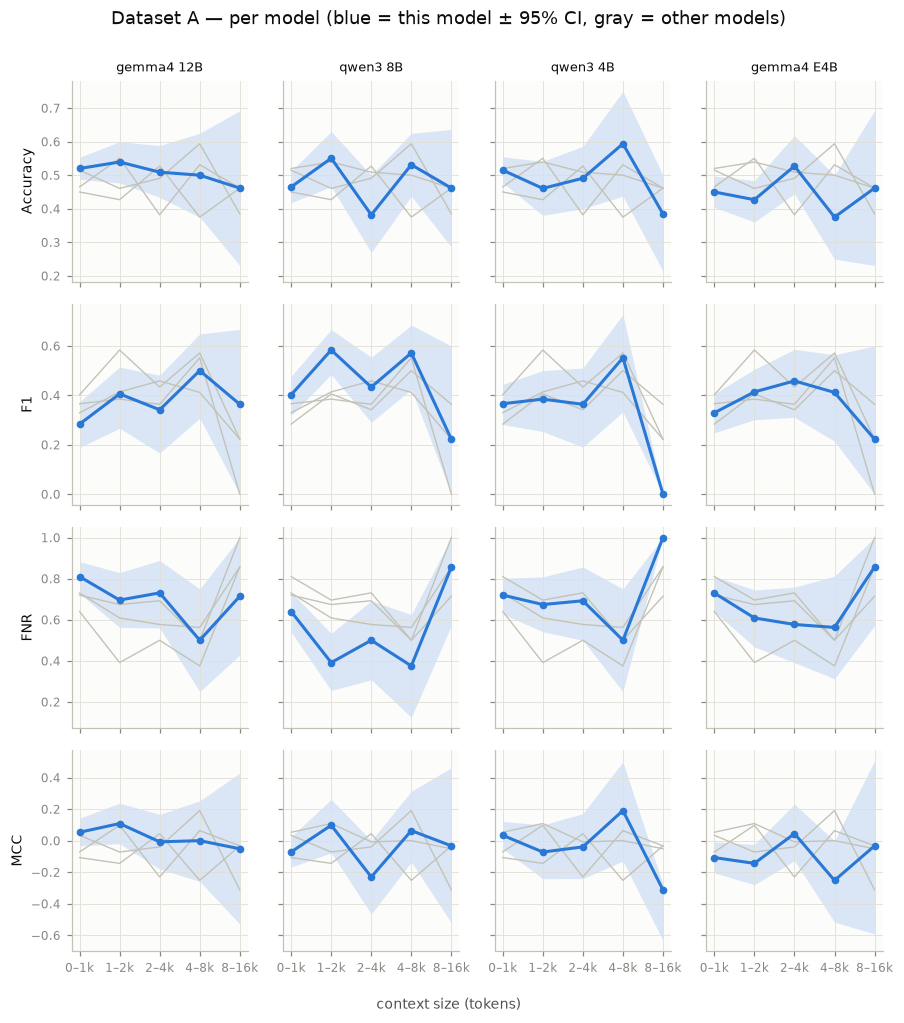

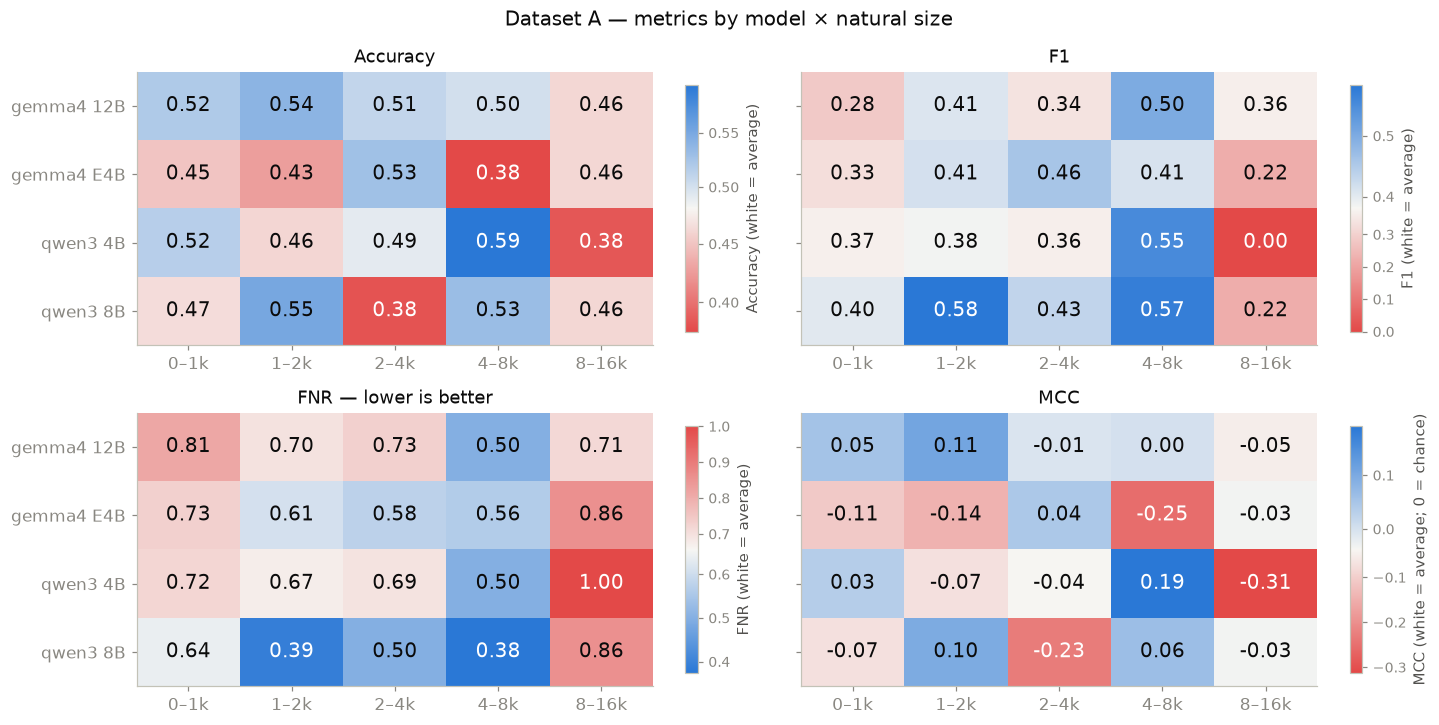

In [6]:
def matrix_figure(tab, size_col, models, title, context_for_model,
                  band_alpha=0.16, note_for_model=None):
    """rows = metrics, cols = models; blue emphasis + gray context per panel.

    context_for_model(model, metric) -> list of (x, y) gray context lines.
    """
    n = len(models)
    fig, axes = plt.subplots(4, n, figsize=(max(2.1 * n, 6.5), 9.2),
                             sharex=True, squeeze=False)
    for i, metric in enumerate(METRIC_NAMES):
        row_vals = []
        for j, model in enumerate(models):
            ax = axes[i][j]
            for cx, cy in context_for_model(model, metric):
                ax.plot(cx, cy, color=GRAY_CTX, lw=0.9, zorder=2)
                row_vals.extend([v for v in cy if np.isfinite(v)])
            g = tab[tab["model"] == model].dropna(subset=[metric])
            if not g.empty:
                x = _size_x(g[size_col], size_col)
                order = np.argsort(x)
                x, y = x[order], g[metric].to_numpy()[order]
                lo = g[f"{metric}_lo"].to_numpy()[order]
                hi = g[f"{metric}_hi"].to_numpy()[order]
                ax.fill_between(x, lo, hi, color=ACCENT, alpha=band_alpha, lw=0)
                ax.plot(x, y, color=ACCENT, lw=2.0, marker="o", ms=4, zorder=3)
                row_vals.extend([v for v in np.r_[lo, hi] if np.isfinite(v)])
            _size_axis(ax, size_col, labels_on=(i == 3))
            if i == 0:
                ax.set_title(short_model(model), color=INK, fontsize=8.5)
                if note_for_model is not None and note_for_model(model):
                    ax.annotate(note_for_model(model), xy=(0.5, 1.18),
                                xycoords="axes fraction", ha="center",
                                fontsize=7, color=MUTED)
            if j == 0:
                ax.set_ylabel(metric, color=INK)
            else:
                ax.tick_params(labelleft=False)
        if row_vals:                     # shared y-limits per metric row
            lo, hi = min(row_vals), max(row_vals)
            pad = 0.06 * (hi - lo + 1e-9)
            for j in range(n):
                axes[i][j].set_ylim(lo - pad, hi + pad)
    fig.suptitle(title, color=INK, fontsize=12, y=1.0)
    fig.supxlabel("context size (tokens)", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()


def metric_heatmaps(tab, size_col, size_order, size_labels, title):
    """2×2 grid of model × size heatmaps. Every panel uses a diverging
    red (bad) → white (panel average) → blue (best) scale, centered on the mean
    of the displayed cells. FNR is reversed (low FNR = blue = good). For MCC the
    scale is likewise relative to the average — remember 0 = chance in absolute
    terms."""
    from matplotlib.colors import TwoSlopeNorm
    n_models = tab["model"].nunique()
    fig, axes = plt.subplots(2, 2, figsize=(1.15 * len(size_order) + 7.6,
                                            0.72 * n_models + 3.8))
    for k, (ax, metric) in enumerate(zip(axes.flat, METRIC_NAMES)):
        piv = (tab.pivot_table(index="model", columns=size_col, values=metric,
                               aggfunc="first", observed=True)
                  .reindex(columns=size_order))
        vals = piv.to_numpy(dtype=float)
        vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
        center = float(np.nanmean(vals))
        if not (vmin < center < vmax):          # flat panel — avoid a broken norm
            vmin, vmax = center - 1e-6, center + 1e-6
        norm = TwoSlopeNorm(vcenter=center, vmin=vmin, vmax=vmax)
        cmap = DIV_CMAP_R if metric == "FNR" else DIV_CMAP
        im = ax.imshow(vals, cmap=cmap, norm=norm, aspect="auto")
        cbar_label = f"{metric} (white = average)"
        if metric == "MCC":
            cbar_label = "MCC (white = average; 0 = chance)"
        for r in range(piv.shape[0]):
            for c in range(piv.shape[1]):
                v = piv.iloc[r, c]
                if pd.isna(v):
                    ax.text(c, r, "—", ha="center", va="center", fontsize=13,
                            color=MUTED)
                    continue
                dark = abs(float(norm(v)) - 0.5) > 0.35   # strong red or strong blue
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=13,
                        color="white" if dark else INK)
        ax.set_xticks(range(len(size_order)), size_labels, fontsize=11)
        if k % 2 == 0:
            ax.set_yticks(range(len(piv)), [short_model(m) for m in piv.index],
                          fontsize=11)
        else:
            ax.set_yticks(range(len(piv)), [""] * len(piv))
        ax.grid(False)
        ax.set_title(metric + (" — lower is better" if metric == "FNR" else ""),
                     color=INK, fontsize=12)
        cb = fig.colorbar(im, ax=ax, shrink=0.9)
        cb.set_label(cbar_label, fontsize=10)
        cb.ax.tick_params(labelsize=9)
    fig.suptitle(title, color=INK, fontsize=13)
    fig.tight_layout()
    plt.show()


if not tab_a.empty:
    ta = tab_a.assign(bucket=tab_a["bucket"].astype(str))
    models_a = ([m for m in A_PLANNED_MODELS if m in set(ta["model"])]
                + sorted(set(ta["model"]) - set(A_PLANNED_MODELS)))

    def _ctx_a(model, metric):
        out = []
        for other, g in ta.groupby("model"):
            if other == model:
                continue
            g = g.dropna(subset=[metric])
            if g.empty:
                continue
            x = _size_x(g["bucket"], "bucket")
            order = np.argsort(x)
            out.append((x[order], g[metric].to_numpy()[order]))
        return out

    matrix_figure(ta, "bucket", models_a,
                  "Dataset A — per model (blue = this model ± 95% CI, gray = other models)",
                  _ctx_a)
    metric_heatmaps(ta, "bucket", BUCKET_ORDER,
                    [BUCKET_LABEL[b] for b in BUCKET_ORDER],
                    "Dataset A — metrics by model × natural size")
else:
    print("No Dataset A results yet.")

## 5. Dataset B — per-model small multiples (budget sweep)

Same layout as §4 for the budget sweep. Metrics pool **all ranking strategies** of a
model (the rankings average); the blue line is the column's model with its 95%
sample-bootstrap CI band, gray lines are the other models. The heatmap grid is the compact all-models view of every metric: red = below the
panel average, white = average, blue = best (FNR's scale is reversed since lower
is better; for MCC the scale is relative to the average, with 0 = chance in
absolute terms).

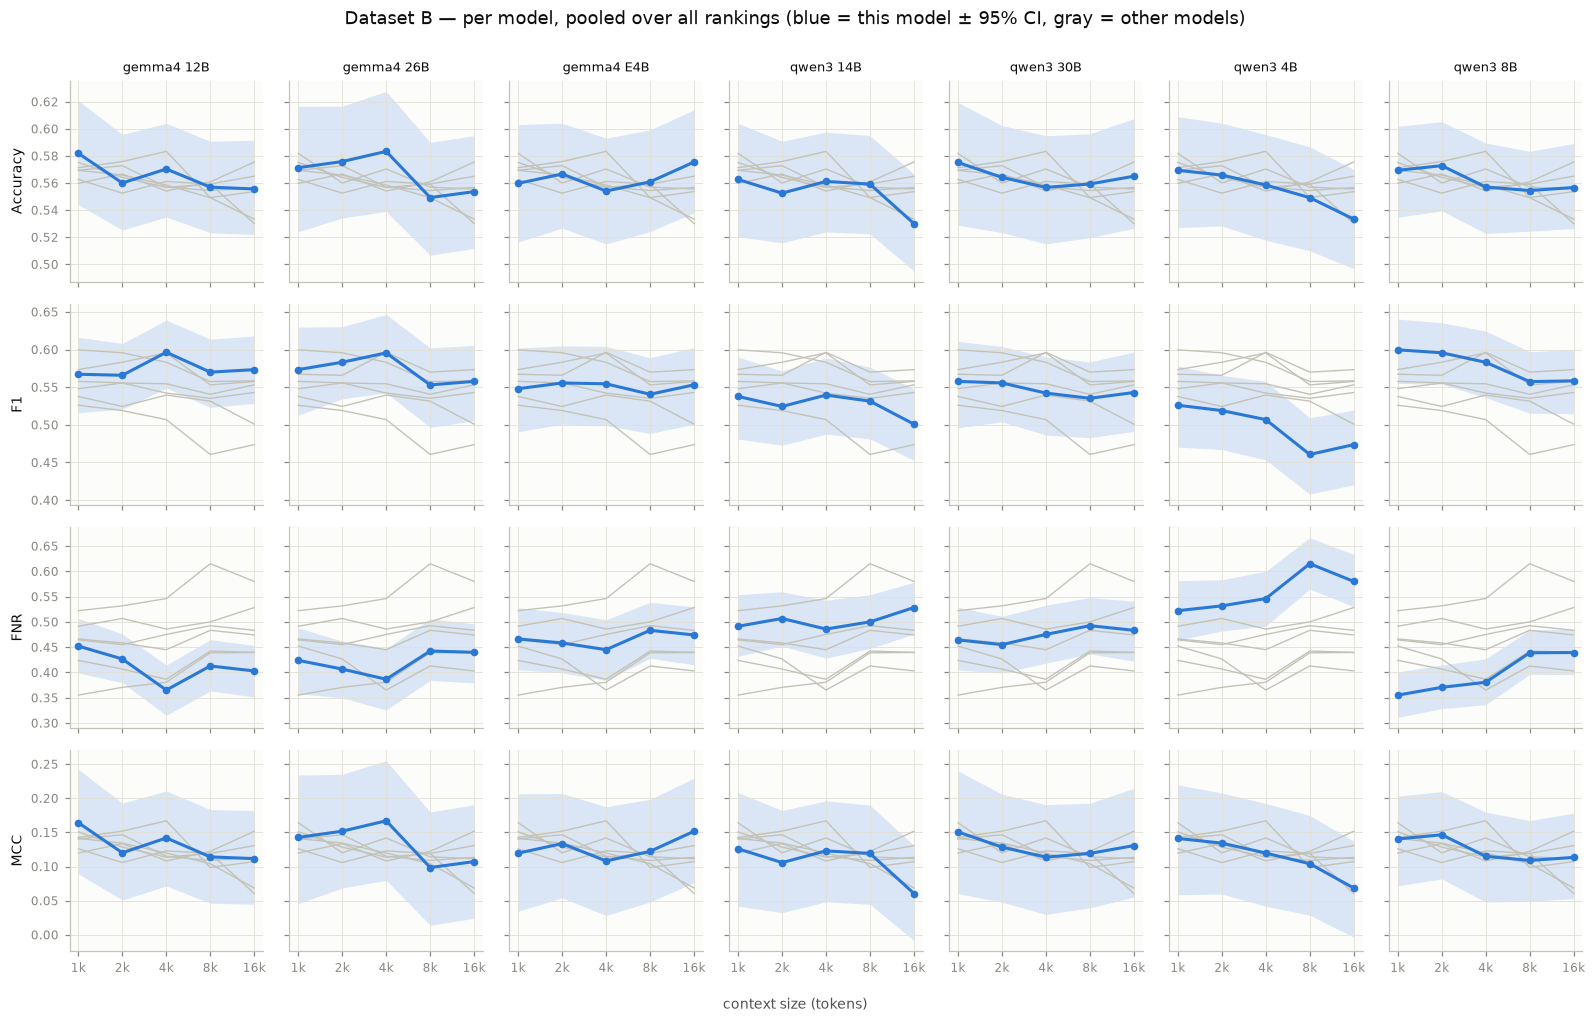

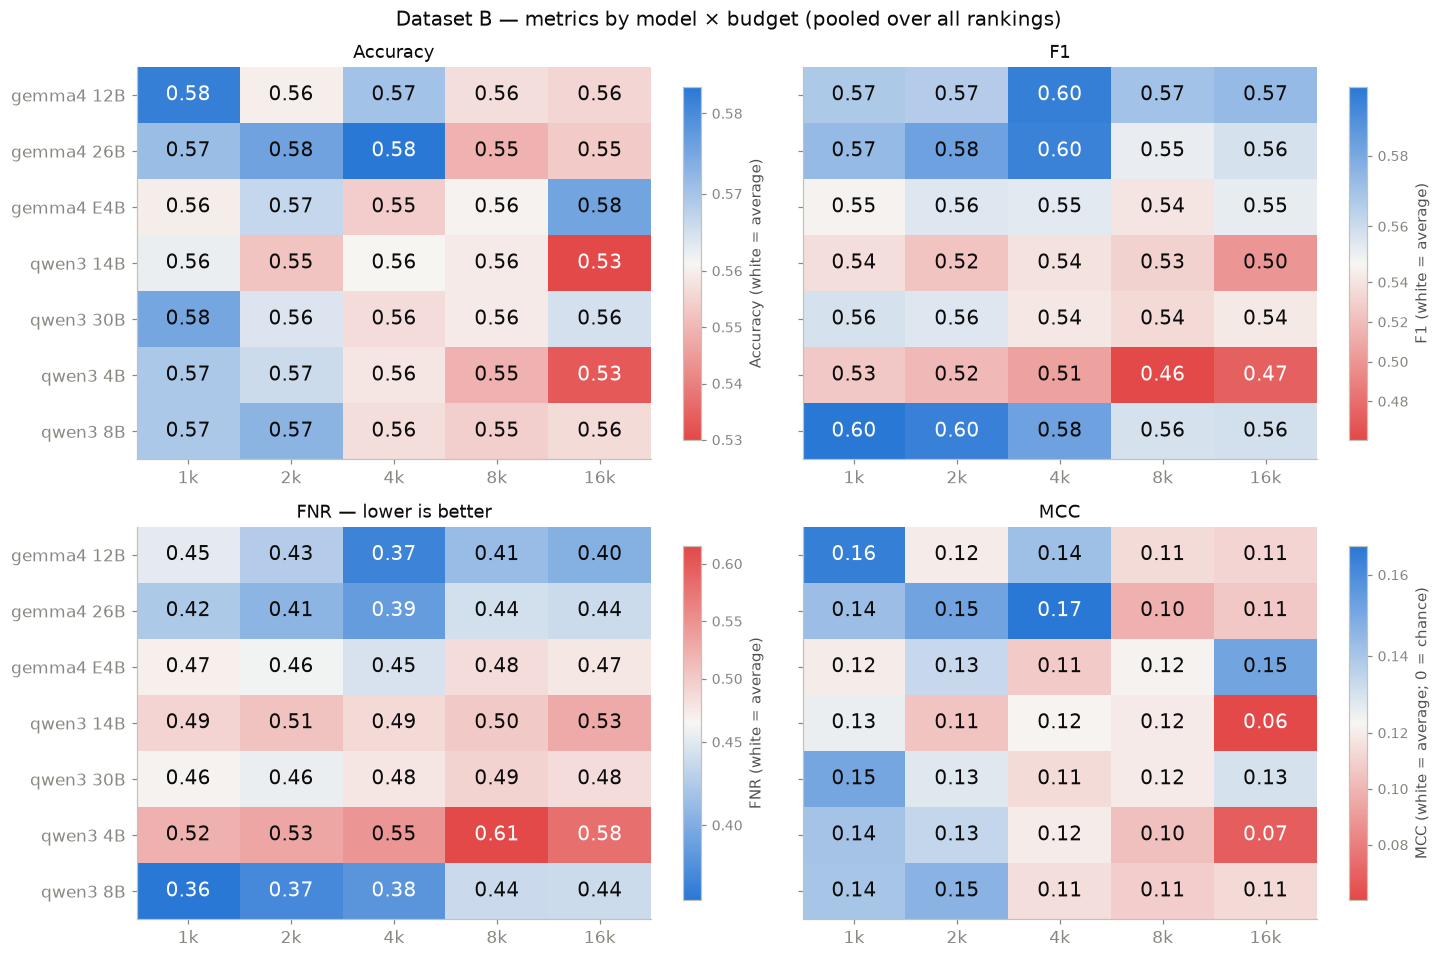

In [7]:
if not tab_b.empty:
    models_b = sorted(tab_b["model"].unique())

    def _ctx_b(model, metric):
        out = []
        for other, g in tab_b.groupby("model"):
            if other == model:
                continue
            g = g.dropna(subset=[metric]).sort_values("budget_k")
            if g.empty:
                continue
            out.append((g["budget_k"].to_numpy(dtype=float), g[metric].to_numpy()))
        return out

    matrix_figure(tab_b, "budget_k", models_b,
                  "Dataset B — per model, pooled over all rankings "
                  "(blue = this model ± 95% CI, gray = other models)",
                  _ctx_b)
    metric_heatmaps(tab_b, "budget_k", BUDGET_ORDER_K,
                    [f"{k}k" for k in BUDGET_ORDER_K],
                    "Dataset B — metrics by model × budget (pooled over all rankings)")
else:
    print("No Dataset B results yet.")

## 6. Statistical methodology

Because the same sample is evaluated at 1k–16k budgets (Dataset B), and because Dataset A
contains a vulnerable/benign pair per commit, observations are **not independent** —
all inference below models that dependence.

**Correctness (primary model)** — mixed-effects logistic regression:

$$\operatorname{logit}\, P(\text{correct}_{i,b}) = \beta_0 + \beta_1 \log_2(b) + \beta_2 \log_2(b)^2 + u_i + u_{\text{project}}$$

where $b$ is the context size ($\log_2 b$ is centered at 4k = $2^{12}$ tokens for numerical
stability), $u_i$ is a random intercept per vulnerability instance (Dataset B: sample;
Dataset A: commit — samples appear only once so the commit is the repeated unit) and
$u_{\text{project}}$ a random intercept per GitHub project. The **quadratic term tests the
inverted-U hypothesis**: $\beta_1 > 0$ and $\beta_2 < 0$ (both CIs excluding 0) means
performance first improves with context and then degrades. In Dataset A, $b$ is the
*measured* per-sample code token count rather than a bucket midpoint.

Fitting uses `statsmodels`' variational-Bayes `BinomialBayesMixedGLM`; reported intervals
are posterior mean ± 1.96 · posterior SD (approximate 95% intervals).

**Pairwise comparisons between context sizes** — Dataset B: **McNemar's test** on paired
correctness (exact binomial when discordant pairs < 25), Dataset A (unpaired buckets):
two-proportion z-tests. All p-values are **Holm-corrected** within each model's family of
pairwise comparisons; Benjamini–Hochberg values are reported alongside.

**F1 / MCC uncertainty** — cluster-bootstrap 95% CIs as in §2.

**Hallucination** — a hallucination is a **false positive on a truly benign sample** (the
model asserts a vulnerability that is not there). On benign samples:

$$\operatorname{logit}\, P(\text{hallucination}_{i,b}) = \gamma_0 + \gamma_1 \log_2(b) + u_i + u_{\text{project}}$$

Parse failures (unparseable model output) are reported separately.

**Latency** — mixed linear model $\text{latency}_{i,b} = \alpha_0 + \alpha_1 b + u_i + \epsilon$
with $b$ in k-tokens (Dataset B; random intercept per sample). For Dataset A we use OLS on
code tokens with project-cluster-robust SEs. *Caveat*: per-sample `processing_time` comes
from batched inference (vLLM continuous batching), so it reflects throughput-shared wall
time, not isolated single-request latency — the slope is still informative for relative cost.

In [8]:
LOG2_CENTER = 12.0  # log2(4096): center of the studied 1k–16k range


def fit_mixed_logistic(d, outcome, size_log2, unit_col, extra_note=""):
    """Variational-Bayes mixed logistic: outcome ~ lb + lb2 + (1|unit) + (1|project)."""
    d = d.copy()
    d["lb"] = size_log2 - LOG2_CENTER
    d["lb2"] = d["lb"] ** 2
    d["_y"] = d[outcome].astype(int)
    d["_unit"] = d[unit_col].astype(str)
    d["_proj"] = d["project"].fillna("unknown").astype(str)
    if d["_y"].nunique() < 2 or d["lb"].nunique() < 3:
        return None
    vc = {"unit": "0 + C(_unit)"}
    if d["_proj"].nunique() > 1:
        vc["project"] = "0 + C(_proj)"
    model = BinomialBayesMixedGLM.from_formula("_y ~ lb + lb2", vc, d)
    fit = model.fit_vb()
    names = fit.model.exog_names
    res = pd.DataFrame({"coef": fit.fe_mean, "sd": fit.fe_sd}, index=names)
    res["ci_lo"] = res["coef"] - 1.96 * res["sd"]
    res["ci_hi"] = res["coef"] + 1.96 * res["sd"]
    return res


def summarize_quadratic(res, label):
    b1, b2 = res.loc["lb"], res.loc["lb2"]
    b1_pos = b1["ci_lo"] > 0
    b2_neg = b2["ci_hi"] < 0
    lines = [f"{label}: β1={b1['coef']:+.3f} [{b1['ci_lo']:+.3f}, {b1['ci_hi']:+.3f}], "
             f"β2={b2['coef']:+.3f} [{b2['ci_lo']:+.3f}, {b2['ci_hi']:+.3f}]"]
    opt_tokens = np.nan
    if b2["coef"] < 0:
        lb_star = -b1["coef"] / (2 * b2["coef"])
        opt_tokens = 2 ** (lb_star + LOG2_CENTER)
        inside = 2**10 <= opt_tokens <= 2**14
        verdict = ("inverted-U CONFIRMED (β1>0, β2<0, CIs exclude 0)" if b1_pos and b2_neg
                   else "concave trend (β2<0) but not conclusive at 95%")
        lines.append(f"   → {verdict}; model-implied optimum ≈ {opt_tokens:,.0f} tokens"
                     + ("" if inside else " (outside studied range — treat as extrapolation)"))
    else:
        trend = "improving" if b1["coef"] > 0 else "degrading"
        lines.append(f"   → no concavity (β2≥0); monotone {trend} trend"
                     + (" (β1 CI excludes 0)" if (b1["ci_lo"] > 0 or b1["ci_hi"] < 0) else
                        " (β1 not significant)"))
    print("\n".join(lines))
    return opt_tokens

### 6.1 Mixed-effects logistic regression — correctness

In [9]:
quad_optima = {}  # (dataset, model) -> model-implied optimal tokens

print("=== Dataset B (repeated measures; all rankings pooled) ===")
if not df_b.empty:
    for model, g in df_b.groupby("model"):
        g = g[g["valid"]]
        if g["budget_k"].nunique() < 3:
            print(f"{model}: <3 budgets available — skipped for now")
            continue
        res = fit_mixed_logistic(g, "correct", np.log2(g["budget_k"] * 1024.0), "sample_id")
        if res is None:
            print(f"{model}: not fittable yet")
            continue
        display(res.round(3).rename_axis(model))
        quad_optima[("B", model)] = summarize_quadratic(res, model)
else:
    print("no data yet")

print("\n=== Dataset A (cross-sectional; b = measured code tokens) ===")
if not df_a.empty:
    for model, g in df_a.groupby("model"):
        g = g[g["valid"] & g["code_tokens"].notna()]
        if len(g) < 50 or g["bucket"].nunique() < 3:
            print(f"{model}: insufficient coverage — skipped for now")
            continue
        res = fit_mixed_logistic(g, "correct", np.log2(g["code_tokens"].astype(float)),
                                 "commit")
        if res is None:
            print(f"{model}: not fittable yet")
            continue
        display(res.round(3).rename_axis(model))
        quad_optima[("A", model)] = summarize_quadratic(res, model)
else:
    print("no data yet")

=== Dataset B (repeated measures; all rankings pooled) ===


/var/opt/llm4codesec-framework/.venv/lib/python3.13/site-packages/statsmodels/genmod/bayes_mixed_glm.py:793: UserWarning: VB fitting did not converge
  warnings.warn("VB fitting did not converge")


,coef,sd,ci_lo,ci_hi
gemma4-12b-it-thinking,,,,
Intercept,0.282,0.016,0.250,0.313
lb,-0.027,0.011,-0.049,-0.005
lb2,0.007,0.006,-0.005,0.019


gemma4-12b-it-thinking: β1=-0.027 [-0.049, -0.005], β2=+0.007 [-0.005, +0.019]
   → no concavity (β2≥0); monotone degrading trend (β1 CI excludes 0)


/var/opt/llm4codesec-framework/.venv/lib/python3.13/site-packages/statsmodels/genmod/bayes_mixed_glm.py:793: UserWarning: VB fitting did not converge
  warnings.warn("VB fitting did not converge")


...

gemma4-e4b-it: β1=+0.005 [-0.059, +0.069], β2=+0.001 [-0.012, +0.015]
   → no concavity (β2≥0); monotone improving trend (β1 not significant)


,coef,sd,ci_lo,ci_hi
qwen3-4b-thinking,,,,
Intercept,-0.019,0.102,-0.219,0.180
lb,-0.063,0.033,-0.127,0.001
lb2,-0.013,0.007,-0.027,0.001


qwen3-4b-thinking: β1=-0.063 [-0.127, +0.001], β2=-0.013 [-0.027, +0.001]
   → concave trend (β2<0) but not conclusive at 95%; model-implied optimum ≈ 750 tokens (outside studied range — treat as extrapolation)


,coef,sd,ci_lo,ci_hi
qwen3-8b-thinking,,,,
Intercept,-0.102,0.102,-0.302,0.098
lb,-0.016,0.033,-0.080,0.048
lb2,-0.003,0.007,-0.017,0.011


qwen3-8b-thinking: β1=-0.016 [-0.080, +0.048], β2=-0.003 [-0.017, +0.011]
   → concave trend (β2<0) but not conclusive at 95%; model-implied optimum ≈ 686 tokens (outside studied range — treat as extrapolation)


### 6.2 Pairwise comparisons between context sizes

Dataset B: McNemar on paired correctness — with rankings pooled, the paired unit is a (sample, ranking) combination, so budgets are compared on identical sample×ranking cells; Dataset A: two-proportion z-test (unpaired).
`p_holm` controls FWER within each model; `p_bh` is the Benjamini–Hochberg FDR value.

In [10]:
def pairwise_b(df_b):
    recs = []
    d0 = df_b[df_b["valid"]].copy()
    d0["unit"] = d0["sample_id"].astype(str) + "|" + d0["ranking"].astype(str)
    for model, g in d0.groupby("model"):
        piv = g.pivot_table(index="unit", columns="budget_k",
                            values="correct", aggfunc="first")
        budgets = [b for b in BUDGET_ORDER_K if b in piv.columns]
        for b1, b2 in combinations(budgets, 2):
            sub = piv[[b1, b2]].dropna()
            if len(sub) < 10:
                continue
            n01 = int(((sub[b1] == 0) & (sub[b2] == 1)).sum())
            n10 = int(((sub[b1] == 1) & (sub[b2] == 0)).sum())
            n11 = int(((sub[b1] == 1) & (sub[b2] == 1)).sum())
            n00 = len(sub) - n01 - n10 - n11
            exact = (n01 + n10) < 25
            p = mcnemar([[n11, n10], [n01, n00]], exact=exact).pvalue
            recs.append({"model": model, "pair": f"{b1}k vs {b2}k", "n": len(sub),
                         "acc_1": sub[b1].mean(), "acc_2": sub[b2].mean(),
                         "discordant": n01 + n10, "p": p})
    return pd.DataFrame(recs)


def pairwise_a(df_a):
    recs = []
    d0 = df_a[df_a["valid"]]
    for model, g in d0.groupby("model"):
        agg = g.groupby("bucket", observed=True)["correct"].agg(["sum", "count"])
        buckets = [b for b in BUCKET_ORDER if b in agg.index and agg.loc[b, "count"] >= 10]
        for b1, b2 in combinations(buckets, 2):
            x = [agg.loc[b1, "sum"], agg.loc[b2, "sum"]]
            n = [agg.loc[b1, "count"], agg.loc[b2, "count"]]
            _, p = proportions_ztest(x, n)
            recs.append({"model": model, "pair": f"{BUCKET_LABEL[b1]} vs {BUCKET_LABEL[b2]}",
                         "n": f"{n[0]}/{n[1]}", "acc_1": x[0] / n[0], "acc_2": x[1] / n[1],
                         "p": p})
    return pd.DataFrame(recs)


def add_corrections(tab):
    if tab.empty:
        return tab
    out = []
    for _, g in tab.groupby("model"):
        g = g.copy()
        g["p_holm"] = multipletests(g["p"], method="holm")[1]
        g["p_bh"] = multipletests(g["p"], method="fdr_bh")[1]
        g["sig(Holm)"] = np.where(g["p_holm"] < ALPHA, "*", "")
        out.append(g)
    return pd.concat(out, ignore_index=True)


pw_b = add_corrections(pairwise_b(df_b)) if not df_b.empty else pd.DataFrame()
pw_a = add_corrections(pairwise_a(df_a)) if not df_a.empty else pd.DataFrame()

if not pw_b.empty:
    print("Dataset B — McNemar (paired on sample × ranking units), Holm/BH corrected:")
    display(pw_b.round(4))
if not pw_a.empty:
    print("Dataset A — two-proportion z-tests (unpaired), Holm/BH corrected:")
    display(pw_a.round(4))

Dataset B — McNemar (paired on sample × ranking units), Holm/BH corrected:


,model,pair,n,acc_1,acc_2,discordant,p,p_holm,p_bh,sig(Holm)
0,gemma4-12b-it-thinking,1k vs 2k,3114,0.5819,0.5520,1499,0.0175,0.1574,0.0652,
1,gemma4-12b-it-thinking,1k vs 4k,3114,0.5819,0.5751,1461,0.6008,1.0000,0.8583,
2,gemma4-12b-it-thinking,1k vs 8k,3114,0.5819,0.5478,1552,0.0077,0.0769,0.0652,
3,gemma4-12b-it-thinking,1k vs 16k,3112,0.5819,0.5521,1553,0.0196,0.1574,0.0652,
4,gemma4-12b-it-thinking,2k vs 4k,3384,0.5591,0.5703,1602,0.3553,1.0000,0.5921,
...,...,...,...,...,...,...,...,...,...,...
65,qwen3-8b-thinking,2k vs 8k,3600,0.5728,0.5544,1686,0.1134,1.0000,0.5300,
66,qwen3-8b-thinking,2k vs 16k,3600,0.5728,0.5567,1808,0.1801,1.0000,0.5300,
67,qwen3-8b-thinking,4k vs 8k,3384,0.5570,0.5505,1662,0.6065,1.0000,0.8664,
68,qwen3-8b-thinking,4k vs 16k,3384,0.5570,0.5570,1628,0.9802,1.0000,0.9802,


Dataset A — two-proportion z-tests (unpaired), Holm/BH corrected:


,model,pair,n,acc_1,acc_2,p,p_holm,p_bh,sig(Holm)
0,gemma4-12b-it-thinking,0–1k vs 1–2k,200/89,0.5200,0.5393,0.7613,1.0000,0.9348,
1,gemma4-12b-it-thinking,0–1k vs 2–4k,200/55,0.5200,0.5091,0.8860,1.0000,0.9348,
2,gemma4-12b-it-thinking,0–1k vs 4–8k,200/32,0.5200,0.5000,0.8335,1.0000,0.9348,
3,gemma4-12b-it-thinking,0–1k vs 8–16k,200/13,0.5200,0.4615,0.6827,1.0000,0.9348,
4,gemma4-12b-it-thinking,1–2k vs 2–4k,89/55,0.5393,0.5091,0.7240,1.0000,0.9348,
5,gemma4-12b-it-thinking,1–2k vs 4–8k,89/32,0.5393,0.5000,0.7023,1.0000,0.9348,
6,gemma4-12b-it-thinking,1–2k vs 8–16k,89/13,0.5393,0.4615,0.5997,1.0000,0.9348,
7,gemma4-12b-it-thinking,2–4k vs 4–8k,55/32,0.5091,0.5000,0.9348,1.0000,0.9348,
8,gemma4-12b-it-thinking,2–4k vs 8–16k,55/13,0.5091,0.4615,0.7578,1.0000,0.9348,
9,gemma4-12b-it-thinking,4–8k vs 8–16k,32/13,0.5000,0.4615,0.8150,1.0000,0.9348,


## 7. Hallucination rate (false positives on benign code) and parse failures

In [11]:
def halluc_table(df, size_col, cluster_col, label_map=None):
    benign = df[df["valid"] & (df["y_true"] == 0)].copy()
    benign["halluc"] = (benign["y_pred"] == 1).astype(int)
    t = (benign.groupby(["model", size_col], observed=True)["halluc"]
               .agg(rate="mean", n="count").reset_index())
    return benign, t


if not df_a.empty:
    ben_a, hal_a = halluc_table(df_a, "bucket", "commit")
if not df_b.empty:
    ben_b, hal_b = halluc_table(df_b, "budget_k", "sample_id")

# hallucination-rate trends are plotted in the §3 overview; per-cell rates:
print("Hallucination rate (FP on truly benign code) per cell:")
if not df_a.empty:
    ha = hal_a.pivot_table(index="model", columns="bucket", values="rate",
                           observed=True)
    ha.columns = [BUCKET_LABEL.get(str(c), str(c)) for c in ha.columns]
    print("Dataset A:")
    display(ha.round(3))
if not df_b.empty:
    hb = hal_b.pivot_table(index="model", columns="budget_k", values="rate")
    print("Dataset B (pooled over all rankings):")
    display(hb.round(3))

# mixed logistic for hallucination (linear log2 term, per user spec)
print("Mixed-effects logistic: hallucination ~ log2(size) + (1|unit) + (1|project)")
def fit_halluc(d, size_log2, unit_col, label):
    d = d.copy()
    d["lb"] = size_log2 - LOG2_CENTER
    d["_y"] = d["halluc"]
    d["_unit"] = d[unit_col].astype(str)
    d["_proj"] = d["project"].fillna("unknown").astype(str)
    if d["_y"].nunique() < 2 or d["lb"].nunique() < 2:
        print(f"{label}: not fittable yet")
        return
    vc = {"unit": "0 + C(_unit)"}
    if d["_proj"].nunique() > 1:
        vc["project"] = "0 + C(_proj)"
    fit = BinomialBayesMixedGLM.from_formula("_y ~ lb", vc, d).fit_vb()
    g1 = dict(zip(fit.model.exog_names, zip(fit.fe_mean, fit.fe_sd)))["lb"]
    lo, hi = g1[0] - 1.96 * g1[1], g1[0] + 1.96 * g1[1]
    direction = ("more hallucinations with larger context" if lo > 0 else
                 "fewer hallucinations with larger context" if hi < 0 else
                 "no significant context-size effect on hallucinations")
    print(f"{label}: γ1 = {g1[0]:+.3f} [{lo:+.3f}, {hi:+.3f}] per doubling → {direction}")


if not df_b.empty:
    for model, g in ben_b.groupby("model"):
        fit_halluc(g, np.log2(g["budget_k"] * 1024.0), "sample_id", f"B / {model}")
if not df_a.empty:
    for model, g in ben_a.groupby("model"):
        g = g[g["code_tokens"].notna()]
        if len(g) >= 50:
            fit_halluc(g, np.log2(g["code_tokens"].astype(float)), "commit", f"A / {model}")

# parse failures
print("\nParse-failure rate (invalid model output) per cell:")
if not df_a.empty:
    pf_a = (1 - df_a.groupby(["model", "bucket"], observed=True)["valid"].mean()).unstack()
    pf_a.columns = [BUCKET_LABEL.get(str(c), str(c)) for c in pf_a.columns]
    print("Dataset A:")
    display(pf_a.round(3))
if not df_b.empty:
    pf_b = (1 - df_b.groupby(["model", "budget_k"])["valid"].mean()).unstack()
    print("Dataset B:")
    display(pf_b.round(3))

Hallucination rate (FP on truly benign code) per cell:
Dataset A:


,0–1k,1–2k,2–4k,4–8k,8–16k
model,,,,,
gemma4-12b-it-thinking,0.15,0.209,0.276,0.500,0.333
gemma4-e4b-it,0.37,0.535,0.379,0.688,0.167
qwen3-4b-thinking,0.25,0.395,0.345,0.312,0.167
qwen3-8b-thinking,0.43,0.512,0.724,0.562,0.167


Dataset B (pooled over all rankings):


budget_k,1,2,4,8,16
model,,,,,
gemma4-12b-it-thinking,0.384,0.453,0.494,0.473,0.486
gemma4-26b-a4b-gguf,0.434,0.442,0.447,0.459,0.453
gemma4-e4b-it,0.414,0.408,0.447,0.395,0.375
qwen3-14b-gguf-thinking,0.383,0.388,0.392,0.382,0.412
qwen3-30b-a3b-instruct-gguf,0.385,0.417,0.411,0.389,0.387
qwen3-4b-thinking,0.339,0.337,0.337,0.287,0.353
qwen3-8b-thinking,0.506,0.484,0.505,0.452,0.447


Mixed-effects logistic: hallucination ~ log2(size) + (1|unit) + (1|project)


...

A / qwen3-4b-thinking: γ1 = +0.144 [+0.034, +0.254] per doubling → more hallucinations with larger context


A / qwen3-8b-thinking: γ1 = +0.251 [+0.153, +0.350] per doubling → more hallucinations with larger context

Parse-failure rate (invalid model output) per cell:
Dataset A:


,0–1k,1–2k,2–4k,4–8k,8–16k
model,,,,,
gemma4-12b-it-thinking,0.0,0.0,0.0,0.0,0.0
gemma4-e4b-it,0.0,0.0,0.0,0.0,0.0
qwen3-4b-thinking,0.0,0.0,0.0,0.0,0.0
qwen3-8b-thinking,0.0,0.0,0.0,0.0,0.0


Dataset B:


budget_k,1,2,4,8,16
model,,,,,
gemma4-12b-it-thinking,0.0,0.0,0.0,0.0,0.0
gemma4-26b-a4b-gguf,0.0,0.0,0.0,0.0,0.0
gemma4-e4b-it,0.0,0.0,0.0,0.0,0.0
qwen3-14b-gguf-thinking,0.0,0.0,0.0,0.0,0.0
qwen3-30b-a3b-instruct-gguf,0.0,0.0,0.0,0.0,0.0
qwen3-4b-thinking,0.0,0.0,0.0,0.0,0.0
qwen3-8b-thinking,0.0,0.0,0.0,0.0,0.0


## 8. Latency vs context size

Mixed linear model per model (Dataset B): $\text{latency} = \alpha_0 + \alpha_1 b + u_i + \epsilon$,
$b$ in k-tokens, random intercept per sample. Dataset A: OLS on measured code tokens with
project-cluster-robust SEs. See the batching caveat in §6.

In [12]:
# latency trends are plotted in the §3 overview; per-cell medians:
print("Median per-sample time (s) per cell:")
if not df_a.empty:
    la = (df_a[df_a["latency_s"].notna()]
          .pivot_table(index="model", columns="bucket", values="latency_s",
                       aggfunc="median", observed=True))
    la.columns = [BUCKET_LABEL.get(str(c), str(c)) for c in la.columns]
    print("Dataset A:")
    display(la.round(2))
if not df_b.empty:
    lb_t = (df_b[df_b["latency_s"].notna()]
            .pivot_table(index="model", columns="budget_k", values="latency_s",
                         aggfunc="median"))
    print("Dataset B (pooled over all rankings):")
    display(lb_t.round(2))

print("Latency models (α1 = added seconds per +1k tokens, 95% CI):")
if not df_b.empty:
    for model, g in df_b[df_b["latency_s"].notna()].groupby("model"):
        if g["budget_k"].nunique() < 3:
            continue
        try:
            fit = smf.mixedlm("latency_s ~ budget_k", g, groups=g["sample_id"]).fit(reml=True)
            ci = fit.conf_int().loc["budget_k"]
            print(f"B / {model}: α1 = {fit.params['budget_k']:+.4f} s/k-token "
                  f"[{ci[0]:+.4f}, {ci[1]:+.4f}]")
        except Exception as e:
            print(f"B / {model}: fit failed ({e})")
if not df_a.empty:
    for model, g in df_a[df_a["latency_s"].notna()
                         & df_a["code_tokens"].notna()].groupby("model"):
        if len(g) < 50:
            continue
        g = g.assign(tok_k=g["code_tokens"] / 1000.0,
                     _proj=g["project"].fillna("unknown"))
        fit = smf.ols("latency_s ~ tok_k", g).fit(cov_type="cluster",
                                                  cov_kwds={"groups": g["_proj"]})
        ci = fit.conf_int().loc["tok_k"]
        print(f"A / {model}: α1 = {fit.params['tok_k']:+.4f} s/k-token "
              f"[{ci[0]:+.4f}, {ci[1]:+.4f}]")

Median per-sample time (s) per cell:
Dataset A:


,0–1k,1–2k,2–4k,4–8k,8–16k
model,,,,,
gemma4-12b-it-thinking,0.82,1.16,1.46,2.20,4.11
gemma4-e4b-it,0.62,0.96,1.31,1.60,2.76
qwen3-4b-thinking,1.08,1.80,2.16,3.46,5.52
qwen3-8b-thinking,1.02,1.33,1.71,2.55,5.19


Dataset B (pooled over all rankings):


budget_k,1,2,4,8,16
model,,,,,
gemma4-12b-it-thinking,1.14,1.02,1.29,1.72,2.48
gemma4-26b-a4b-gguf,4.47,4.54,4.69,4.96,5.14
gemma4-e4b-it,0.82,0.90,1.09,1.30,1.68
qwen3-14b-gguf-thinking,1.58,1.78,2.18,2.63,3.54
qwen3-30b-a3b-instruct-gguf,5.06,5.83,6.70,7.01,7.57
qwen3-4b-thinking,1.77,2.00,2.35,2.74,3.51
qwen3-8b-thinking,0.81,0.90,1.27,1.83,2.94


Latency models (α1 = added seconds per +1k tokens, 95% CI):


...

B / gemma4-e4b-it: α1 = +0.0444 s/k-token [+0.0437, +0.0451]


B / qwen3-14b-gguf-thinking: α1 = +0.0981 s/k-token [+0.0964, +0.0998]


B / qwen3-30b-a3b-instruct-gguf: α1 = +0.2389 s/k-token [+0.1928, +0.2850]


B / qwen3-4b-thinking: α1 = +0.0917 s/k-token [+0.0905, +0.0930]


B / qwen3-8b-thinking: α1 = +0.1167 s/k-token [+0.1158, +0.1176]
A / gemma4-12b-it-thinking: α1 = +0.2738 s/k-token [+0.2480, +0.2996]
A / gemma4-e4b-it: α1 = +0.1888 s/k-token [+0.1699, +0.2078]
A / qwen3-4b-thinking: α1 = +0.4017 s/k-token [+0.3607, +0.4427]
A / qwen3-8b-thinking: α1 = +0.3340 s/k-token [+0.3006, +0.3674]


## 9. Which context size is most effective?

Per model and dataset: the empirically best context size by MCC (primary) and F1, whether
the best size beats the alternatives after Holm correction, and the quadratic-model
optimum from §6.1 where the fit was concave.

In [13]:
def best_sizes(tab, size_col, fmt):
    recs = []
    for model, g in tab.groupby("model", observed=True):
        g = g.dropna(subset=["MCC"])
        if g.empty:
            continue
        bm = g.loc[g["MCC"].idxmax()]
        bf = g.loc[g["F1"].idxmax()] if g["F1"].notna().any() else bm
        recs.append({
            "model": model,
            "best size (MCC)": fmt(bm[size_col]),
            "MCC": f"{bm['MCC']:.3f} [{bm['MCC_lo']:.3f}, {bm['MCC_hi']:.3f}]",
            "best size (F1)": fmt(bf[size_col]),
            "F1": f"{bf['F1']:.3f} [{bf['F1_lo']:.3f}, {bf['F1_hi']:.3f}]",
        })
    return pd.DataFrame(recs)


summary_frames = []
if not tab_b.empty:
    sb = best_sizes(tab_b, "budget_k", lambda v: f"{int(v)}k")
    sb["quadratic optimum"] = sb["model"].map(
        lambda m: f"{quad_optima[('B', m)]:,.0f} tok" if ("B", m) in quad_optima
        and np.isfinite(quad_optima[("B", m)]) else "—")
    sb.insert(0, "dataset", "B (budget sweep)")
    summary_frames.append(sb)
if not tab_a.empty:
    sa = best_sizes(tab_a.assign(bucket=tab_a["bucket"].astype(str)), "bucket",
                    lambda v: BUCKET_LABEL.get(v, v))
    sa["quadratic optimum"] = sa["model"].map(
        lambda m: f"{quad_optima[('A', m)]:,.0f} tok" if ("A", m) in quad_optima
        and np.isfinite(quad_optima[("A", m)]) else "—")
    sa.insert(0, "dataset", "A (natural size)")
    summary_frames.append(sa)

if summary_frames:
    best_summary = pd.concat(summary_frames, ignore_index=True)
    display(best_summary)

    # generated verdict
    print("Verdict (auto-generated from currently available results):")
    for _, r in best_summary.iterrows():
        print(f" - {r['dataset']} / {r['model']}: MCC peaks at {r['best size (MCC)']} "
              f"(MCC {r['MCC']}), F1 peaks at {r['best size (F1)']}"
              + (f"; quadratic model optimum ≈ {r['quadratic optimum']}"
                 if r["quadratic optimum"] != "—" else ""))
    if not pw_b.empty:
        n_sig = int((pw_b["p_holm"] < ALPHA).sum())
        print(f"\nOf {len(pw_b)} paired budget comparisons in Dataset B, "
              f"{n_sig} remain significant after Holm correction "
              f"(see §6.2 for which pairs).")
else:
    print("No results available yet.")

,dataset,model,best size (MCC),MCC,best size (F1),F1,quadratic optimum
0,B (budget sweep),gemma4-12b-it-thinking,1k,"0.164 [0.089, 0.242]",4k,"0.596 [0.549, 0.639]",—
1,B (budget sweep),gemma4-26b-a4b-gguf,4k,"0.167 [0.080, 0.255]",4k,"0.596 [0.542, 0.647]","2,009 tok"
2,B (budget sweep),gemma4-e4b-it,16k,"0.152 [0.076, 0.229]",2k,"0.556 [0.501, 0.605]",—
3,B (budget sweep),qwen3-14b-gguf-thinking,1k,"0.126 [0.042, 0.208]",4k,"0.540 [0.488, 0.589]","2,387 tok"
4,B (budget sweep),qwen3-30b-a3b-instruct-gguf,1k,"0.151 [0.060, 0.240]",1k,"0.558 [0.496, 0.611]",—
5,B (budget sweep),qwen3-4b-thinking,1k,"0.141 [0.059, 0.220]",1k,"0.526 [0.470, 0.578]",561 tok
6,B (budget sweep),qwen3-8b-thinking,2k,"0.146 [0.082, 0.210]",1k,"0.600 [0.555, 0.640]",—
7,A (natural size),gemma4-12b-it-thinking,1–2k,"0.108 [-0.019, 0.238]",4–8k,"0.500 [0.307, 0.649]",825 tok
8,A (natural size),gemma4-e4b-it,2–4k,"0.045 [-0.127, 0.231]",2–4k,"0.458 [0.311, 0.586]",—
9,A (natural size),qwen3-4b-thinking,4–8k,"0.191 [-0.129, 0.500]",4–8k,"0.552 [0.333, 0.727]",750 tok


Verdict (auto-generated from currently available results):
 - B (budget sweep) / gemma4-12b-it-thinking: MCC peaks at 1k (MCC 0.164 [0.089, 0.242]), F1 peaks at 4k
 - B (budget sweep) / gemma4-26b-a4b-gguf: MCC peaks at 4k (MCC 0.167 [0.080, 0.255]), F1 peaks at 4k; quadratic model optimum ≈ 2,009 tok
 - B (budget sweep) / gemma4-e4b-it: MCC peaks at 16k (MCC 0.152 [0.076, 0.229]), F1 peaks at 2k
 - B (budget sweep) / qwen3-14b-gguf-thinking: MCC peaks at 1k (MCC 0.126 [0.042, 0.208]), F1 peaks at 4k; quadratic model optimum ≈ 2,387 tok
 - B (budget sweep) / qwen3-30b-a3b-instruct-gguf: MCC peaks at 1k (MCC 0.151 [0.060, 0.240]), F1 peaks at 1k
 - B (budget sweep) / qwen3-4b-thinking: MCC peaks at 1k (MCC 0.141 [0.059, 0.220]), F1 peaks at 1k; quadratic model optimum ≈ 561 tok
 - B (budget sweep) / qwen3-8b-thinking: MCC peaks at 2k (MCC 0.146 [0.082, 0.210]), F1 peaks at 1k
 - A (natural size) / gemma4-12b-it-thinking: MCC peaks at 1–2k (MCC 0.108 [-0.019, 0.238]), F1 peaks at 4–8k; q

## 10. Final report table (paper-ready)

One row per model × context size with all four metrics and bootstrap 95% CIs. Exported as
LaTeX (booktabs) and CSV to `benchmarks/tables/`.

In [14]:
def paper_table(tab, size_col, size_fmt, dataset_label):
    if tab.empty:
        return pd.DataFrame()
    rows = []
    for _, r in tab.iterrows():
        def cell(m):
            if pd.isna(r[m]):
                return "—"
            return f"{r[m]:.3f} [{r[f'{m}_lo']:.3f}, {r[f'{m}_hi']:.3f}]"
        rows.append({"Model": r["model"], "Context size": size_fmt(r[size_col]),
                     "n": int(r["n"]), "Accuracy": cell("Accuracy"), "F1": cell("F1"),
                     "FNR": cell("FNR"), "MCC": cell("MCC")})
    out = pd.DataFrame(rows)
    # order sizes naturally within model
    return out


paper_a = paper_table(tab_a.assign(bucket=tab_a["bucket"].astype(str)) if not tab_a.empty
                      else tab_a, "bucket", lambda v: BUCKET_LABEL.get(v, v), "A")
paper_b = paper_table(tab_b, "budget_k", lambda v: f"{int(v)}k", "B")

for name, tab, caption in [
    ("context_size_cleanvul", paper_a,
     "CleanVul (Python): detection metrics by natural sample size. "
     "95\\% commit-cluster bootstrap CIs in brackets."),
    ("context_size_budget_sweep", paper_b,
     "ContextAssembler: detection metrics by context budget, pooled over all "
     "context-ranking strategies. "
     "95\\% sample-bootstrap CIs in brackets; identical samples across budgets."),
]:
    if tab.empty:
        continue
    print(f"— {name} —")
    display(tab)
    tab.to_csv(TABLES_DIR / f"{name}.csv", index=False)
    latex = tab.to_latex(index=False, escape=True,
                         caption=caption, label=f"tab:{name}")
    (TABLES_DIR / f"{name}.tex").write_text(latex)
    print(f"saved → {TABLES_DIR / (name + '.csv')} and .tex")

— context_size_cleanvul —


,Model,Context size,n,Accuracy,F1,FNR,MCC
0,gemma4-12b-it-thinking,0–1k,200,"0.520 [0.488, 0.553]","0.284 [0.189, 0.374]","0.810 [0.727, 0.882]","0.053 [-0.033, 0.143]"
1,gemma4-12b-it-thinking,1–2k,89,"0.539 [0.477, 0.600]","0.406 [0.267, 0.514]","0.696 [0.562, 0.830]","0.108 [-0.019, 0.238]"
2,gemma4-12b-it-thinking,2–4k,55,"0.509 [0.434, 0.588]","0.341 [0.167, 0.481]","0.731 [0.560, 0.889]","-0.007 [-0.180, 0.167]"
3,gemma4-12b-it-thinking,4–8k,32,"0.500 [0.375, 0.625]","0.500 [0.307, 0.649]","0.500 [0.250, 0.750]","0.000 [-0.258, 0.252]"
4,gemma4-12b-it-thinking,8–16k,13,"0.462 [0.231, 0.692]","0.364 [0.000, 0.667]","0.714 [0.429, 1.000]","-0.051 [-0.529, 0.429]"
5,gemma4-e4b-it,0–1k,200,"0.450 [0.404, 0.497]","0.329 [0.248, 0.406]","0.730 [0.640, 0.812]","-0.107 [-0.204, -0.008]"
6,gemma4-e4b-it,1–2k,89,"0.427 [0.360, 0.484]","0.414 [0.301, 0.505]","0.609 [0.468, 0.745]","-0.144 [-0.279, -0.024]"
7,gemma4-e4b-it,2–4k,55,"0.527 [0.444, 0.618]","0.458 [0.311, 0.586]","0.577 [0.391, 0.759]","0.045 [-0.127, 0.231]"
8,gemma4-e4b-it,4–8k,32,"0.375 [0.250, 0.500]","0.412 [0.214, 0.564]","0.562 [0.312, 0.812]","-0.252 [-0.516, 0.000]"
9,gemma4-e4b-it,8–16k,13,"0.462 [0.231, 0.692]","0.222 [0.000, 0.600]","0.857 [0.571, 1.000]","-0.033 [-0.592, 0.507]"


saved → /var/opt/llm4codesec-framework/benchmarks/tables/context_size_cleanvul.csv and .tex
— context_size_budget_sweep —


,Model,Context size,n,Accuracy,F1,FNR,MCC
0,gemma4-12b-it-thinking,1k,3114,"0.582 [0.544, 0.621]","0.567 [0.516, 0.616]","0.452 [0.399, 0.507]","0.164 [0.089, 0.242]"
1,gemma4-12b-it-thinking,2k,3600,"0.560 [0.525, 0.596]","0.566 [0.521, 0.608]","0.427 [0.380, 0.476]","0.120 [0.051, 0.193]"
2,gemma4-12b-it-thinking,4k,3384,"0.570 [0.535, 0.604]","0.596 [0.549, 0.639]","0.365 [0.315, 0.415]","0.142 [0.072, 0.211]"
3,gemma4-12b-it-thinking,8k,3600,"0.557 [0.523, 0.591]","0.570 [0.523, 0.614]","0.413 [0.364, 0.465]","0.114 [0.046, 0.183]"
4,gemma4-12b-it-thinking,16k,3598,"0.556 [0.522, 0.592]","0.573 [0.528, 0.618]","0.403 [0.351, 0.454]","0.112 [0.045, 0.182]"
5,gemma4-26b-a4b-gguf,1k,1038,"0.571 [0.524, 0.617]","0.573 [0.513, 0.630]","0.424 [0.358, 0.488]","0.143 [0.046, 0.234]"
6,gemma4-26b-a4b-gguf,2k,1200,"0.576 [0.534, 0.617]","0.583 [0.535, 0.630]","0.407 [0.350, 0.462]","0.152 [0.069, 0.235]"
7,gemma4-26b-a4b-gguf,4k,1128,"0.583 [0.539, 0.628]","0.596 [0.542, 0.647]","0.387 [0.326, 0.447]","0.167 [0.080, 0.255]"
8,gemma4-26b-a4b-gguf,8k,1198,"0.549 [0.507, 0.590]","0.553 [0.497, 0.602]","0.442 [0.384, 0.506]","0.099 [0.014, 0.180]"
9,gemma4-26b-a4b-gguf,16k,1091,"0.554 [0.512, 0.595]","0.558 [0.506, 0.606]","0.440 [0.379, 0.496]","0.107 [0.024, 0.190]"


saved → /var/opt/llm4codesec-framework/benchmarks/tables/context_size_budget_sweep.csv and .tex


## 11. Interpretation notes

* **Dataset B is the cleaner experiment** for the context-size question: the sample set is
  fixed across budgets, so any metric movement is attributable to the context budget (plus
  sampling noise handled by the paired tests). Dataset A confounds size with sample
  identity — larger functions may be intrinsically harder — which is why its regression
  uses measured `code_tokens` with commit/project random intercepts rather than bucket
  comparisons alone.
* **MCC is the headline metric**: with balanced-ish classes and models that over- or
  under-predict "vulnerable" at different context sizes, accuracy and F1 can move in
  opposite directions; MCC summarizes the full confusion matrix.
* An **inverted-U** (β₁ > 0, β₂ < 0) supports the "lost in the middle / context dilution"
  hypothesis: some context helps localize the vulnerability, too much buries it.
* The 8–16k CleanVul bucket is currently tiny (see coverage) — treat its point estimates
  as provisional until the dataset is regenerated with more large samples.
* GGUF models (`qwen3-30b-a3b-instruct-gguf`, `gemma4-26b-a4b-gguf-thinking`) and
  remaining `gemma4-e4b-it` buckets will appear automatically in every table/plot once
  their runs finish — simply re-execute the notebook.